<a href="https://colab.research.google.com/github/mars8577/CSC.htm/blob/main/mental_and_substance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"
import plotly.figure_factory as ff


In [106]:
from google.colab import files
uploaded = files.upload()

Saving mental_health_and_substance.csv to mental_health_and_substance (2).csv


In [107]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("mental_health_and_substance.csv")
df

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,1.696670
1,Afghanistan,AFG,1991,1.734281
2,Afghanistan,AFG,1992,1.791189
3,Afghanistan,AFG,1993,1.776779
4,Afghanistan,AFG,1994,1.712986
...,...,...,...,...
6835,Zimbabwe,ZWE,2015,2.193166
6836,Zimbabwe,ZWE,2016,2.279813
6837,Zimbabwe,ZWE,2017,2.364265
6838,Zimbabwe,ZWE,2018,2.472949


In [108]:
df.head()
print(df.head())


        Entity Code  Year  \
0  Afghanistan  AFG  1990   
1  Afghanistan  AFG  1991   
2  Afghanistan  AFG  1992   
3  Afghanistan  AFG  1993   
4  Afghanistan  AFG  1994   

   DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
0                                           1.696670                                                
1                                           1.734281                                                
2                                           1.791189                                                
3                                           1.776779                                                
4                                           1.712986                                                


In [109]:
df.info()
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 4 columns):
 #   Column                                                                                           Non-Null Count  Dtype  
---  ------                                                                                           --------------  -----  
 0   Entity                                                                                           6840 non-null   object 
 1   Code                                                                                             6150 non-null   object 
 2   Year                                                                                             6840 non-null   int64  
 3   DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  6840 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 213.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839


In [110]:
df.shape
print(df.shape)

(6840, 4)


In [111]:
df.columns
print(df.columns)

Index(['Entity', 'Code', 'Year',
       'DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)'],
      dtype='object')


In [112]:
df.describe()
print(df.describe())

              Year  \
count  6840.000000   
mean   2004.500000   
std       8.656074   
min    1990.000000   
25%    1997.000000   
50%    2004.500000   
75%    2012.000000   
max    2019.000000   

       DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
count                                        6840.000000                                                
mean                                            4.818062                                                
std                                             2.294029                                                
min                                             0.215647                                                
25%                                             3.006507                                                
50%                                             4.679177                                                
75%                                             6.387488          

In [113]:
df.isnull().sum()
print(df.isnull().sum)

<bound method DataFrame.sum of       Entity   Code   Year  \
0      False  False  False   
1      False  False  False   
2      False  False  False   
3      False  False  False   
4      False  False  False   
...      ...    ...    ...   
6835   False  False  False   
6836   False  False  False   
6837   False  False  False   
6838   False  False  False   
6839   False  False  False   

      DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
0                                                 False                                                
1                                                 False                                                
2                                                 False                                                
3                                                 False                                                
4                                                 False                                 

In [114]:
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
6835,False
6836,False
6837,False
6838,False


In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df = df.drop_duplicates()
print(df)

           Entity Code  Year  \
0     Afghanistan  AFG  1990   
1     Afghanistan  AFG  1991   
2     Afghanistan  AFG  1992   
3     Afghanistan  AFG  1993   
4     Afghanistan  AFG  1994   
...           ...  ...   ...   
6835     Zimbabwe  ZWE  2015   
6836     Zimbabwe  ZWE  2016   
6837     Zimbabwe  ZWE  2017   
6838     Zimbabwe  ZWE  2018   
6839     Zimbabwe  ZWE  2019   

      DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
0                                              1.696670                                                
1                                              1.734281                                                
2                                              1.791189                                                
3                                              1.776779                                                
4                                              1.712986                                        

In [117]:
df = df.fillna(0)
print(df)

           Entity Code  Year  \
0     Afghanistan  AFG  1990   
1     Afghanistan  AFG  1991   
2     Afghanistan  AFG  1992   
3     Afghanistan  AFG  1993   
4     Afghanistan  AFG  1994   
...           ...  ...   ...   
6835     Zimbabwe  ZWE  2015   
6836     Zimbabwe  ZWE  2016   
6837     Zimbabwe  ZWE  2017   
6838     Zimbabwe  ZWE  2018   
6839     Zimbabwe  ZWE  2019   

      DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
0                                              1.696670                                                
1                                              1.734281                                                
2                                              1.791189                                                
3                                              1.776779                                                
4                                              1.712986                                        

In [118]:
recent = df[df['Year'] > 2010]
print(recent)

           Entity Code  Year  \
21    Afghanistan  AFG  2011   
22    Afghanistan  AFG  2012   
23    Afghanistan  AFG  2013   
24    Afghanistan  AFG  2014   
25    Afghanistan  AFG  2015   
...           ...  ...   ...   
6835     Zimbabwe  ZWE  2015   
6836     Zimbabwe  ZWE  2016   
6837     Zimbabwe  ZWE  2017   
6838     Zimbabwe  ZWE  2018   
6839     Zimbabwe  ZWE  2019   

      DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
21                                             3.211115                                                
22                                             3.311809                                                
23                                             3.431008                                                
24                                             3.444342                                                
25                                             3.460077                                        

In [119]:
df['Year'].describe()

,Year
count,6840.000000
mean,2004.500000
std,8.656074
min,1990.000000
25%,1997.000000
50%,2004.500000
75%,2012.000000
max,2019.000000


In [120]:
df['DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)'].describe()

,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
count,6840.000000
mean,4.818062
std,2.294029
min,0.215647
25%,3.006507
50%,4.679177
75%,6.387488
max,13.761517


In [121]:
df['Entity']

,Entity
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
...,...
6835,Zimbabwe
6836,Zimbabwe
6837,Zimbabwe
6838,Zimbabwe


In [122]:
df[['Entity', 'Year']]

,Entity,Year
0,Afghanistan,1990
1,Afghanistan,1991
2,Afghanistan,1992
3,Afghanistan,1993
4,Afghanistan,1994
...,...,...
6835,Zimbabwe,2015
6836,Zimbabwe,2016
6837,Zimbabwe,2017
6838,Zimbabwe,2018


In [123]:
df[df['Entity'] == 'Afghanistan']

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,1.696670
1,Afghanistan,AFG,1991,1.734281
2,Afghanistan,AFG,1992,1.791189
3,Afghanistan,AFG,1993,1.776779
4,Afghanistan,AFG,1994,1.712986
5,Afghanistan,AFG,1995,1.738272
6,Afghanistan,AFG,1996,1.778098
7,Afghanistan,AFG,1997,1.781815
8,Afghanistan,AFG,1998,1.729402
9,Afghanistan,AFG,1999,1.850988


In [124]:
df[(df['Entity'] == 'Afghanistan') & (df['Year'] > 2010)]

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
21,Afghanistan,AFG,2011,3.211115
22,Afghanistan,AFG,2012,3.311809
23,Afghanistan,AFG,2013,3.431008
24,Afghanistan,AFG,2014,3.444342
25,Afghanistan,AFG,2015,3.460077
26,Afghanistan,AFG,2016,3.505517
27,Afghanistan,AFG,2017,3.729269
28,Afghanistan,AFG,2018,3.817517
29,Afghanistan,AFG,2019,3.991275


In [125]:
df.sort_values('Year', ascending=False)

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
6089,Trinidad and Tobago,TTO,2019,5.852887
6059,Tonga,TON,2019,4.718312
3869,Morocco,MAR,2019,7.574394
3599,Mauritania,MRT,2019,4.038174
3629,Mauritius,MUS,2019,5.271867
...,...,...,...,...
270,Armenia,ARM,1990,3.959785
6810,Zimbabwe,ZWE,1990,2.232313
6300,United Kingdom,GBR,1990,6.170815
6330,United States,USA,1990,6.193336


In [126]:
mental_recent =[df['Year'] > 1990 ]
print(mental_recent)


[0       False
1        True
2        True
3        True
4        True
        ...  
6835     True
6836     True
6837     True
6838     True
6839     True
Name: Year, Length: 6840, dtype: bool]


In [127]:
mental_recent = df[df['Year'] > 1990]
print(mental_recent.head())

        Entity Code  Year  \
1  Afghanistan  AFG  1991   
2  Afghanistan  AFG  1992   
3  Afghanistan  AFG  1993   
4  Afghanistan  AFG  1994   
5  Afghanistan  AFG  1995   

   DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  
1                                           1.734281                                                
2                                           1.791189                                                
3                                           1.776779                                                
4                                           1.712986                                                
5                                           1.738272                                                


In [128]:
mental_recent = df[df['Year'] > 1990]
print(mental_recent.shape)

(6612, 4)


In [129]:
df.groupby('Year').mean(numeric_only=True)

,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
Year,
1990,4.049826
1991,4.102394
1992,4.154714
1993,4.186789
1994,4.223421
1995,4.267119
1996,4.341400
1997,4.399449
1998,4.465881


In [130]:
df.groupby('Entity').mean(numeric_only=True)

,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
Entity,,
Afghanistan,2004.5,2.553085
African Region (WHO),2004.5,1.940398
Albania,2004.5,5.276702
Algeria,2004.5,6.451224
American Samoa,2004.5,4.529481
...,...,...
World Bank Lower Middle Income,2004.5,3.207812
World Bank Upper Middle Income,2004.5,5.006917
Yemen,2004.5,3.470172


In [131]:
df.sort_values(
    by='DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)',
    ascending=False
)

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
4797,Qatar,QAT,2017,13.761517
4798,Qatar,QAT,2018,13.720572
4796,Qatar,QAT,2016,13.692509
4799,Qatar,QAT,2019,13.670201
4795,Qatar,QAT,2015,13.608391
...,...,...,...,...
4113,Niger,NER,1993,0.738998
4112,Niger,NER,1992,0.730513
4111,Niger,NER,1991,0.712380
4110,Niger,NER,1990,0.711836


In [132]:
df = df.rename(columns={'DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)': 'Mental_Health_Impact'
})
print(df.columns)

Index(['Entity', 'Code', 'Year', 'Mental_Health_Impact'], dtype='object')


In [133]:
df['Mental_Health_Impact'].describe()

,Mental_Health_Impact
count,6840.000000
mean,4.818062
std,2.294029
min,0.215647
25%,3.006507
50%,4.679177
75%,6.387488
max,13.761517


In [134]:
top_countries = df.groupby('Entity')['Mental_Health_Impact'].mean().sort_values(ascending=False)
print(top_countries.head(10))

Entity
Qatar                   10.954817
Bahrain                 10.903130
Kuwait                  10.826324
Australia                9.563027
United Arab Emirates     9.489214
Israel                   9.038432
Andorra                  8.990529
New Zealand              8.809220
Ireland                  8.760704
Chile                    8.685382
Name: Mental_Health_Impact, dtype: float64


In [135]:
south_america = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile',
    'Colombia', 'Ecuador', 'Guyana', 'Paraguay',
    'Peru', 'Suriname', 'Uruguay', 'Venezuela'
]

sa_df = df[df['Entity'].isin(south_america)]
print(sa_df)

         Entity Code  Year  Mental_Health_Impact
240   Argentina  ARG  1990              5.316919
241   Argentina  ARG  1991              5.368712
242   Argentina  ARG  1992              5.405815
243   Argentina  ARG  1993              5.483222
244   Argentina  ARG  1994              5.567589
...         ...  ...   ...                   ...
6505  Venezuela  VEN  2015              5.996038
6506  Venezuela  VEN  2016              5.983430
6507  Venezuela  VEN  2017              5.884263
6508  Venezuela  VEN  2018              5.825585
6509  Venezuela  VEN  2019              5.743737

[360 rows x 4 columns]


In [136]:
top_countries =sa_df.groupby('Entity')['Mental_Health_Impact'].mean().sort_values(ascending=False)
print(top_countries.head(40))

Entity
Chile        8.685382
Paraguay     7.352707
Brazil       6.677690
Ecuador      6.019737
Argentina    5.951120
Peru         5.752882
Venezuela    5.711444
Suriname     5.661605
Uruguay      5.656895
Colombia     5.437014
Guyana       4.592657
Bolivia      4.279673
Name: Mental_Health_Impact, dtype: float64


In [137]:
sa_df = df[df['Entity'].isin(south_america)]
sa_df

,Entity,Code,Year,Mental_Health_Impact
240,Argentina,ARG,1990,5.316919
241,Argentina,ARG,1991,5.368712
242,Argentina,ARG,1992,5.405815
243,Argentina,ARG,1993,5.483222
244,Argentina,ARG,1994,5.567589
...,...,...,...,...
6505,Venezuela,VEN,2015,5.996038
6506,Venezuela,VEN,2016,5.983430
6507,Venezuela,VEN,2017,5.884263
6508,Venezuela,VEN,2018,5.825585


In [138]:
sa_years = (
    sa_df.groupby('Year')['Mental_Health_Impact']
    .mean()
)

print(sa_years.idxmax())  # year
print(sa_years.max())     # value

2019
6.7031523005


In [139]:
print(sa_df['Mental_Health_Impact'].mean())
print(df['Mental_Health_Impact'].mean())

5.981567135836111
4.818061811758918


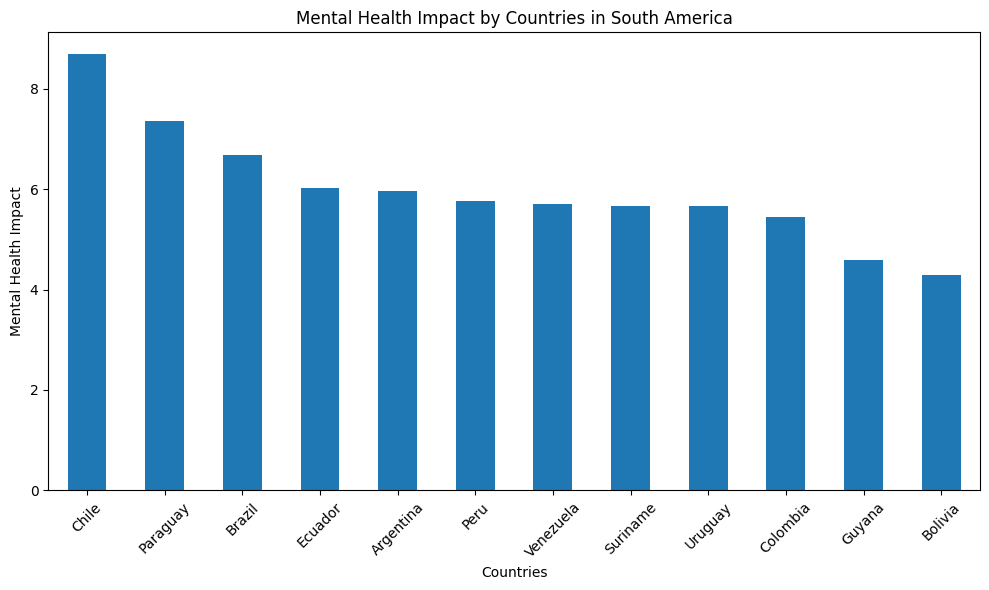

In [140]:
top_countries_sa = (
    sa_df.groupby('Entity')['Mental_Health_Impact']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
top_countries_sa.plot(kind='bar')

plt.title('Mental Health Impact by Countries in South America')
plt.xlabel('Countries')
plt.ylabel('Mental Health Impact')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [141]:
greater_antilles = [
    'Cuba',
    'Jamaica',
    'Haiti',
    'Dominican Republic'
    ]

lesser_antilles = [
    'Antigua  and Barbuda'
    'Dominica',
    'Grenada',
    'Saint Luncia',
    'Saint Vincent and the Grenadines',
    'Saint Kitts and Navis',
    'Barbados',
    'Trinida and Tobago'
]

bahamas_group = [
    'Bahamas'
]

print(greater_antilles)
print(lesser_antilles)
print(bahamas_group)


['Cuba', 'Jamaica', 'Haiti', 'Dominican Republic']
['Antigua  and BarbudaDominica', 'Grenada', 'Saint Luncia', 'Saint Vincent and the Grenadines', 'Saint Kitts and Navis', 'Barbados', 'Trinida and Tobago']
['Bahamas']


In [142]:
df['Caribbean_Region'] = 'Other'

df.loc[df['Entity'].isin(greater_antilles), 'Caribbean_Region'] = 'Greater Antilles'
df.loc[df['Entity'].isin(lesser_antilles), 'Caribbean_Region'] = 'Lesser Antilles'
df.loc[df['Entity'].isin(bahamas_group), 'Caribbean_Region'] = 'Bahamas'

print(df['Caribbean_Region'].value_counts())



Caribbean_Region
Other               6600
Greater Antilles     120
Lesser Antilles       90
Bahamas               30
Name: count, dtype: int64


In [143]:
Caribbean_Region_avg = (
    df[df['Caribbean_Region'] != 'Other']
    .groupby('Caribbean_Region')['Mental_Health_Impact']
    .mean()
    .sort_values(ascending=False)
)

print(Caribbean_Region_avg)

Caribbean_Region
Bahamas             5.601211
Lesser Antilles     5.550311
Greater Antilles    5.396215
Name: Mental_Health_Impact, dtype: float64


In [144]:
Caribbean_Region_avg = Caribbean_Region_avg.reset_index()

print(Caribbean_Region_avg.head())

   Caribbean_Region  Mental_Health_Impact
0           Bahamas              5.601211
1   Lesser Antilles              5.550311
2  Greater Antilles              5.396215


In [145]:
fig = px.bar(
    Caribbean_Region_avg,
    x='Caribbean_Region',
    y='Mental_Health_Impact',
    title='Average Mental Health Impact by Caribbean Region'
)

fig.show()

In [146]:
print(df['Entity'].unique())

['Afghanistan' 'African Region (WHO)' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire" 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Democratic Republic of Congo' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'East Asia & Pacific (WB)'
 'Eastern Mediterranean Region (WHO)' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe & Central Asia (WB)' 'European Region (WHO)' 'Fiji' 'Finland'
 'France' 'G20' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Greenland' 'Grenad

In [148]:
yearly_Mental_Health_Impact = df.groupby('Year')['Mental_Health_Impact'].mean()
print(yearly_Mental_Health_Impact)

Year
1990    4.049826
1991    4.102394
1992    4.154714
1993    4.186789
1994    4.223421
1995    4.267119
1996    4.341400
1997    4.399449
1998    4.465881
1999    4.518323
2000    4.592549
2001    4.661567
2002    4.707870
2003    4.761088
2004    4.814102
2005    4.886157
2006    4.940883
2007    4.999224
2008    5.040548
2009    5.091247
2010    5.158852
2011    5.208496
2012    5.251699
2013    5.300023
2014    5.318322
2015    5.344732
2016    5.380123
2017    5.418583
2018    5.461459
2019    5.495016
Name: Mental_Health_Impact, dtype: float64


In [149]:
yearly_Mental_Health_Impact = df.groupby('Entity')['Mental_Health_Impact'].mean()
print(yearly_Mental_Health_Impact)

Entity
Afghanistan                       2.553085
African Region (WHO)              1.940398
Albania                           5.276702
Algeria                           6.451224
American Samoa                    4.529481
                                    ...   
World Bank Lower Middle Income    3.207812
World Bank Upper Middle Income    5.006917
Yemen                             3.470172
Zambia                            1.664278
Zimbabwe                          1.743918
Name: Mental_Health_Impact, Length: 228, dtype: float64


In [150]:
most_countries =sa_df.groupby('Entity')['Mental_Health_Impact'].mean().sort_values(ascending=False)
print(top_countries.head(40))

Entity
Chile        8.685382
Paraguay     7.352707
Brazil       6.677690
Ecuador      6.019737
Argentina    5.951120
Peru         5.752882
Venezuela    5.711444
Suriname     5.661605
Uruguay      5.656895
Colombia     5.437014
Guyana       4.592657
Bolivia      4.279673
Name: Mental_Health_Impact, dtype: float64


In [151]:
caribbean = [
    'Haiti', 'Jamaica', 'Cuba', 'Dominican Republic',
    'Bahamas', 'Barbados', 'Trinidad and Tobago',
    'Grenada', 'Saint Lucia', 'Saint Vincent and the Grenadines',
    'Antigua and Barbuda', 'Dominica',
    'Saint Kitts and Nevis'
]
caribbean_df = df[df['Entity'].isin(caribbean)]
print(caribbean_df)

                   Entity Code  Year  Mental_Health_Impact Caribbean_Region
210   Antigua and Barbuda  ATG  1990              5.889292            Other
211   Antigua and Barbuda  ATG  1991              5.905187            Other
212   Antigua and Barbuda  ATG  1992              5.896195            Other
213   Antigua and Barbuda  ATG  1993              5.768496            Other
214   Antigua and Barbuda  ATG  1994              5.793440            Other
...                   ...  ...   ...                   ...              ...
6085  Trinidad and Tobago  TTO  2015              6.038429            Other
6086  Trinidad and Tobago  TTO  2016              5.959567            Other
6087  Trinidad and Tobago  TTO  2017              5.909507            Other
6088  Trinidad and Tobago  TTO  2018              5.876193            Other
6089  Trinidad and Tobago  TTO  2019              5.852887            Other

[390 rows x 5 columns]


In [152]:
top_caribbean_df = (
    caribbean_df.groupby('Entity')['Mental_Health_Impact'].mean().sort_values(ascending=False))
print(top_caribbean_df)



Entity
Cuba                                7.488879
Antigua and Barbuda                 6.496132
Jamaica                             6.213926
Saint Lucia                         5.933545
Trinidad and Tobago                 5.746132
Barbados                            5.692676
Grenada                             5.657169
Saint Kitts and Nevis               5.601966
Bahamas                             5.601211
Dominican Republic                  5.407154
Saint Vincent and the Grenadines    5.301088
Dominica                            4.736856
Haiti                               2.474899
Name: Mental_Health_Impact, dtype: float64


In [ ]:
caribbean_years = (
    caribbean_df.groupby('Year')['Mental_Health_Impact']
    .mean()
)

print(caribbean_years.idxmax())  # year
print(caribbean_years.max())     # value

In [ ]:
print(caribbean_df['Mental_Health_Impact'].mean())
print(sa_df['Mental_Health_Impact'].mean())

In [ ]:
top_caribbean = (
     caribbean_df.groupby('Entity')['Mental_Health_Impact'].mean().sort_values(ascending=False))

plt.figure(figsize=(10, 6))
top_caribbean.plot(kind='bar')
plt.title('Mental Health Impact by Country in the Caribbean')
plt.xlabel('Country')
plt.ylabel('Mental Health Impact')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [154]:
top_caribbean = (
    caribbean_df.groupby('Year')['Mental_Health_Impact']
    .mean()
    .reset_index()
)

print(top_caribbean.head())

   Year  Mental_Health_Impact
0  1990              5.017989
1  1991              5.092314
2  1992              5.097245
3  1993              5.090875
4  1994              5.109800


In [155]:
import plotly.express as px

fig = px.line(
    top_caribbean,
    x='Year',
    y='Mental_Health_Impact',
    title='Mental Health Impact in Caribbean Countries Over Time'
)

fig.show()

In [156]:
df['Caribbean_Position'] = 'Other'

western = ['Jamaica', 'Cuba']

central = ['Haiti', 'Dominican Republic']

eastern = [
    'Antigua and Barbuda',
    'Dominica',
    'Grenada',
    'Saint Lucia',
    'Saint Vincent and the Grenadines',
    'Saint Kitts and Nevis',
    'Barbados',
    'Trinidad and Tobago'
]

northern = ['Bahamas']

df.loc[df['Entity'].isin(western), 'Caribbean_Position'] = 'Western Caribbean'
df.loc[df['Entity'].isin(central), 'Caribbean_Position'] = 'Central Caribbean'
df.loc[df['Entity'].isin(eastern), 'Caribbean_Position'] = 'Eastern Caribbean'
df.loc[df['Entity'].isin(northern), 'Caribbean_Position'] = 'Northern Caribbean'
print(caribbean_df)

                   Entity Code  Year  Mental_Health_Impact Caribbean_Region
210   Antigua and Barbuda  ATG  1990              5.889292            Other
211   Antigua and Barbuda  ATG  1991              5.905187            Other
212   Antigua and Barbuda  ATG  1992              5.896195            Other
213   Antigua and Barbuda  ATG  1993              5.768496            Other
214   Antigua and Barbuda  ATG  1994              5.793440            Other
...                   ...  ...   ...                   ...              ...
6085  Trinidad and Tobago  TTO  2015              6.038429            Other
6086  Trinidad and Tobago  TTO  2016              5.959567            Other
6087  Trinidad and Tobago  TTO  2017              5.909507            Other
6088  Trinidad and Tobago  TTO  2018              5.876193            Other
6089  Trinidad and Tobago  TTO  2019              5.852887            Other

[390 rows x 5 columns]


In [157]:
position_avg = (
    df[df['Caribbean_Position'] != 'Other']
    .groupby('Caribbean_Position')['Mental_Health_Impact']
    .mean()
    .sort_values(ascending=False)
)

print(position_avg)

Caribbean_Position
Western Caribbean     6.851402
Eastern Caribbean     5.645696
Northern Caribbean    5.601211
Central Caribbean     3.941027
Name: Mental_Health_Impact, dtype: float64


In [167]:
north = ['Colombia', 'Venezuela', 'Guyana', 'Suriname']
west = ['Ecuador', 'Peru', 'Bolivia', 'Chile']
east = ['Brazil']
south = ['Argentina', 'Uruguay', 'Paraguay']

# Ensure 'SA_Position' column exists in df before filtering
if 'SA_Position' not in df.columns:
    df['SA_Position'] = 'Other'
    df.loc[df['Entity'].isin(north), 'SA_Position'] = 'North'
    df.loc[df['Entity'].isin(west), 'SA_Position'] = 'West'
    df.loc[df['Entity'].isin(east), 'SA_Position'] = 'East'
    df.loc[df['Entity'].isin(south), 'SA_Position'] = 'South'

sa_position_avg = (
    df[df['SA_Position'] != 'Other']
    .groupby('SA_Position')['Mental_Health_Impact']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


fig = px.bar(
    sa_position_avg,
    x='SA_Position',
    y='Mental_Health_Impact',
    color='SA_Position',
    color_discrete_map={
        'North': 'blue',
        'West': 'green',
        'East': 'orange',
        'South': 'red'
    },
    title='Average Mental Health Impact by South America Region'
)


fig.show()

In [164]:
north = ['Colombia', 'Venezuela', 'Guyana', 'Suriname']

west = ['Ecuador', 'Peru', 'Bolivia', 'Chile']

east = ['Brazil']

south = ['Argentina', 'Uruguay', 'Paraguay']

df['SA_Position'] = 'Other'

df.loc[df['Entity'].isin(north), 'SA_Position'] = 'North'
df.loc[df['Entity'].isin(west), 'SA_Position'] = 'West'
df.loc[df['Entity'].isin(east), 'SA_Position'] = 'East'
df.loc[df['Entity'].isin(south), 'SA_Position'] = 'South'
print(sa_df)


         Entity Code  Year  Mental_Health_Impact
240   Argentina  ARG  1990              5.316919
241   Argentina  ARG  1991              5.368712
242   Argentina  ARG  1992              5.405815
243   Argentina  ARG  1993              5.483222
244   Argentina  ARG  1994              5.567589
...         ...  ...   ...                   ...
6505  Venezuela  VEN  2015              5.996038
6506  Venezuela  VEN  2016              5.983430
6507  Venezuela  VEN  2017              5.884263
6508  Venezuela  VEN  2018              5.825585
6509  Venezuela  VEN  2019              5.743737

[360 rows x 4 columns]


In [165]:
South_america = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile',
    'Colombia', 'Ecuador', 'Guyana', 'Paraguay',
    'Peru', 'Suriname', 'Uruguay', 'Venezuela'
]

position_avg = (
    df[df['SA_Position'] != 'Other']
    .groupby('SA_Position')['Mental_Health_Impact']
    .mean()
    .sort_values(ascending=False)
)

print(position_avg)

SA_Position
East     6.677690
South    6.320241
West     6.184419
North    5.350680
Name: Mental_Health_Impact, dtype: float64


In [168]:
import plotly.express as px
South_america = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile',
    'Colombia', 'Ecuador', 'Guyana', 'Paraguay',
    'Peru', 'Suriname', 'Uruguay', 'Venezuela'
]

position_avg = position_avg.reset_index()

fig = px.bar(
    position_avg,
    x='SA_Position',
    y='Mental_Health_Impact',
    color='SA_Position',
    color_discrete_map={
        'North': 'red',
        'West': 'purple',
        'East': 'yellow',
        'South': 'brown'
    },
    title='Average Mental Health Impact by South Region'
)

fig.show()

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

x = df[['Year']]
y = df[['Mental_Health_Impact']]

print(x.shape)
print(y.shape)

(6840, 1)
(6840, 1)


In [171]:
x = df[['Year']]
y = df[['Mental_Health_Impact']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5472, 1)
(1368, 1)
(5472, 1)
(1368, 1)


In [172]:
train_test_split(x, y, test_size=0.2, random_state=42)
LinearRegression().fit(x_train, y_train)



LinearRegression()

In [173]:
train_test_split(x, y, test_size=0.2, random_state=42)



[      Year
 2251  1991
 977   2007
 809   2019
 2436  1996
 2228  1998
 ...    ...
 3772  2012
 5191  1991
 5226  1996
 5390  2010
 860   2010
 
 [5472 rows x 1 columns],
       Year
 3238  2018
 3805  2015
 435   2005
 3758  1998
 5985  2005
 ...    ...
 4856  2016
 240   1990
 783   1993
 1354  1994
 1018  2018
 
 [1368 rows x 1 columns],
       Mental_Health_Impact
 2251              1.872139
 977               1.754444
 809               7.489703
 2436              1.168729
 2228              6.188675
 ...                    ...
 3772              6.075271
 5191              4.094425
 5226              4.384766
 5390              2.347092
 860               3.416652
 
 [5472 rows x 1 columns],
       Mental_Health_Impact
 3238              2.185686
 3805              4.182769
 435              11.379611
 3758              6.035028
 5985              1.898409
 ...                    ...
 4856              4.063498
 240               5.316919
 783               5.153087
 1354       

In [176]:
fig = px.scatter(
    df,
    x = 'Year',
    y = 'Mental_Health_Impact',
    color='Year',
    color_discrete_map={
        'North': 'red',
        'West': 'purple',
        'East': 'yellow',
        'South': 'brown'
    },
    title = 'Mental Health Impact Over Time'
)

fig.show()

In [183]:
fig = px.bar(
    df[df['SA_Position'] != 'Other'],
    x='Year',
    y='Mental_Health_Impact',
    color='SA_Position',
    color_discrete_map={
        'North': 'blue',
        'West': 'purple',
        'East': 'green',
        'South': 'black'
    },
    title='Mental Health Impact by South America Region'
)

fig.show()


In [189]:
fig = px.choropleth(
    df,
    locations='Code',
    color='Mental_Health_Impact',
    hover_name='Entity',
    animation_frame='Year',
    color_continuous_scale='Viridis',
    title='Mental Health Impact by Country'
)

fig.show()

In [190]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)


Ridge()

In [204]:
ridge_pred = ridge.predict(x_test)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"Ridge R2: {ridge_r2}")
print(f"Ridge MAE: {ridge_mae}")
print(f"Ridge RMSE: {ridge_rmse}")

Ridge R2: 0.02560700323731191
Ridge MAE: 1.817743599059826
Ridge RMSE: 2.226299236618837


In [205]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train, y_train)
Lasso_pred = lasso.predict(x_test)
lasso_r2 = r2_score(y_test, Lasso_pred)
lasso_mae = mean_absolute_error(y_test, Lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, Lasso_pred))

print(f"Lasso R2: {lasso_r2}")
print(f"Lasso MAE: {lasso_mae}")
print(f"Lasso RMSE: {lasso_rmse}")

Lasso R2: 0.027174714395335253
Lasso MAE: 1.8098102380431509
Lasso RMSE: 2.2245075575176134


In [216]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train, y_train)
Lasso_pred = lasso.predict(x_test)
lasso_r2 = r2_score(y_test, Lasso_pred)
lasso_mae = mean_absolute_error(y_test, Lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, Lasso_pred))

print(f"Lasso R2: {lasso_r2}")
print(f"Lasso MAE: {lasso_mae}")
print(f"Lasso RMSE: {lasso_rmse}")

Lasso R2: 0.027174714395335253
Lasso MAE: 1.8098102380431509
Lasso RMSE: 2.2245075575176134


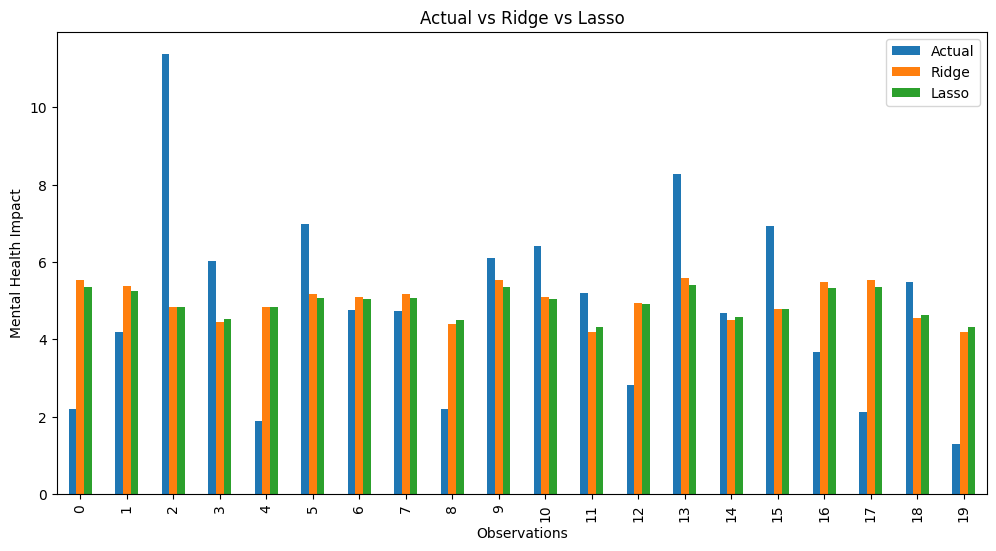

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    'Actual': np.ravel(y_test),
    'Ridge': np.ravel(ridge_pred),
    'Lasso': np.ravel(Lasso_pred)
}).reset_index(drop=True)

plot_df.iloc[:20].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Actual vs Ridge vs Lasso')
plt.xlabel('Observations')
plt.ylabel('Mental Health Impact')

plt.show()